# Descriptive Statistics
## S&P 500 10-K Sample · Returns · Fama-French Six-Factor Data

| Panel | Unit of observation | Source |
|---|---|---|
| A | Firm-filing (unique accession) | `lazy_prices_dataset.csv` |
| B | Firm-month | `lazy_prices_dataset.csv` |
| C | Calendar month | Ken French Data Library |

All continuous variables are winsorised at the 1st and 99th percentiles.
Financial variables are in USD millions unless stated otherwise.

## 0. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


## 1. Configuration

In [2]:
import os

CONFIG = {
    'returns_path':      '/content/drive/MyDrive/FML_project_4/lazy_prices_dataset.csv',
    'usable_pairs_path': '/content/drive/MyDrive/FML_project_4/usable_pairs.parquet',
    'output_folder':     '/content/drive/MyDrive/FML_project_4',
    'winsor':  0.01,   # 1%/99% symmetric winsorisation
    'ff_start': '2004-01',
    'ff_end':   '2025-12',
}
print('Config OK')

Config OK


## 2. Dependencies

In [3]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'pyarrow', 'pandas-datareader', 'statsmodels'], check=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas_datareader.data as web

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('OK')

OK


## 3. Load & Clean Data

In [4]:
raw = pd.read_csv(CONFIG['returns_path'])
raw['fdate']          = pd.to_datetime(raw['fdate'],        errors='coerce')
raw['return_month']   = pd.to_datetime(raw['return_month'], errors='coerce')
raw['datadate']       = pd.to_datetime(raw['datadate'],     errors='coerce')
raw['cik']            = raw['cik'].astype(str).str.strip().str.lstrip('0')
raw['monthly_return'] = pd.to_numeric(raw['monthly_return'], errors='coerce')
for col in ['at', 'sale', 'ni']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Apply usable-pairs filter (S&P 500 membership × has 10-K)
raw['year'] = raw['fdate'].dt.year.astype('Int64')
usable = pd.read_parquet(CONFIG['usable_pairs_path'])
usable['cik']  = usable['cik'].astype(str).str.strip().str.lstrip('0')
usable['year'] = usable['year'].astype('Int64')
usable_set     = set(zip(usable['cik'], usable['year'].astype(int)))
raw = raw[raw.apply(lambda r: (r['cik'], int(r['year'])) in usable_set, axis=1)].copy()

print(f'Rows after filter : {len(raw):,}')
print(f'Unique CIKs       : {raw["cik"].nunique():,}')
print(f'Date range        : {raw["return_month"].min().date()} \u2013 {raw["return_month"].max().date()}')

Rows after filter : 10,969
Unique CIKs       : 897
Date range        : 2004-03-31 – 2024-12-31


## 4. Construct Analysis Variables

In [5]:
# ── Panel A: firm-filing level (one row per unique accession) ─────────
filings = (
    raw.sort_values('fdate')
       .drop_duplicates(subset=['cik', 'accession'], keep='first')
       .copy()
)
filings['roa']            = filings['ni']   / filings['at']
filings['asset_turnover'] = filings['sale'] / filings['at']
filings['ros']            = filings['ni']   / filings['sale']
filings['log_at']         = np.log(filings['at'].where(filings['at'] > 0))
filings['filing_month']   = filings['fdate'].dt.month   # 1=Jan ... 12=Dec
filings['filing_lag']     = (
    (filings['fdate'] - filings['datadate']).dt.days / 30.44
)  # months between fiscal year-end and filing

print(f'Firm-filing observations : {len(filings):,}')
print(f'Unique CIKs              : {filings["cik"].nunique():,}')
print(f'Filing years             : {filings["year"].min()} \u2013 {filings["year"].max()}')

# ── Panel B: firm-month level (unique cik × return_month) ────────────
monthly = (
    raw[['cik', 'return_month', 'monthly_return']]
    .drop_duplicates(subset=['cik', 'return_month'])
    .sort_values(['cik', 'return_month'])
    .reset_index(drop=True)
)
monthly['monthly_return'] = pd.to_numeric(monthly['monthly_return'], errors='coerce')
g = monthly.groupby('cik')

# Reversal: prior month return
monthly['reversal'] = g['monthly_return'].shift(1)

# Momentum: cumulative return months t-12 to t-2
log_r = np.log1p(monthly['monthly_return'].fillna(0))
monthly['momentum'] = np.expm1(
    monthly.assign(log_r=log_r)
           .groupby('cik')['log_r']
           .transform(lambda x: x.shift(2).rolling(11, min_periods=8).sum())
)

# Annualised return (12-month forward buy-and-hold, aligned per filing)
monthly['ret_year'] = monthly['return_month'].dt.year

print(f'\nFirm-month observations  : {len(monthly):,}')
print(f'Calendar months covered  : {monthly["return_month"].nunique():,}')

Firm-filing observations : 10,278
Unique CIKs              : 897
Filing years             : 2004 – 2024

Firm-month observations  : 8,367
Calendar months covered  : 177


## 5. Fama-French Six-Factor Data

In [6]:
# FF5 (Fama-French 2015) + Momentum = six-factor model
try:
    ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench',
                         start=CONFIG['ff_start'], end=CONFIG['ff_end'])[0] / 100
    mom = web.DataReader('F-F_Momentum_Factor', 'famafrench',
                         start=CONFIG['ff_start'], end=CONFIG['ff_end'])[0] / 100
    ff5.index = pd.PeriodIndex(ff5.index, freq='M').to_timestamp()
    mom.index = pd.PeriodIndex(mom.index, freq='M').to_timestamp()
    factors = ff5.join(mom, how='inner').rename(columns={'Mom': 'UMD'})
    # Columns: Mkt-RF, SMB, HML, RMW, CMA, RF, UMD
    factors.columns = [c.strip() for c in factors.columns]
    HAS_FF = True
    print(f'FF6 loaded: {len(factors)} months  '
          f'({factors.index.min().date()} \u2013 {factors.index.max().date()})')
    print(f'Columns: {list(factors.columns)}')
except Exception as exc:
    print(f'Could not load FF data: {exc}')
    HAS_FF = False

FF6 loaded: 264 months  (2004-01-01 – 2025-12-01)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'UMD']


## 6. Winsorise

In [7]:
def winsorize(s: pd.Series, p: float) -> pd.Series:
    lo = s.quantile(p)
    hi = s.quantile(1 - p)
    return s.clip(lower=lo, upper=hi)

WIN_FILING = ['at', 'sale', 'ni', 'log_at', 'roa', 'asset_turnover', 'ros', 'filing_lag']
WIN_MONTHLY = ['monthly_return', 'momentum', 'reversal']

for col in WIN_FILING:
    if col in filings.columns:
        filings[col] = winsorize(filings[col], CONFIG['winsor'])

for col in WIN_MONTHLY:
    if col in monthly.columns:
        monthly[col] = winsorize(monthly[col], CONFIG['winsor'])

print('Winsorisation complete.')

Winsorisation complete.


## 7. Descriptive Statistics Tables

Tables follow the format of Fama & French (2015) and Cohen, Malloy & Nguyen (2020):
mean, standard deviation, and selected percentiles reported for each variable.

In [8]:
def desc_row(label: str, s: pd.Series) -> dict:
    s = s.dropna()
    return {
        'Variable': label,
        'N':        f'{len(s):,}',
        'Mean':     f'{s.mean():.4f}',
        'Std Dev':  f'{s.std():.4f}',
        'p10':      f'{s.quantile(.10):.4f}',
        'p25':      f'{s.quantile(.25):.4f}',
        'Median':   f'{s.quantile(.50):.4f}',
        'p75':      f'{s.quantile(.75):.4f}',
        'p90':      f'{s.quantile(.90):.4f}',
        'Skewness': f'{s.skew():.3f}',
    }

COLS = ['Variable', 'N', 'Mean', 'Std Dev', 'p10', 'p25', 'Median', 'p75', 'p90', 'Skewness']

# ─────────────────────────────────────────────────────────────────────
# Panel A: Firm-level financial characteristics (one obs per filing)
# ─────────────────────────────────────────────────────────────────────
panel_a_vars = [
    ('Total Assets ($m)',        filings['at']),
    ('log(Total Assets)',        filings['log_at']),
    ('Revenue ($m)',             filings['sale']),
    ('Net Income ($m)',          filings['ni']),
    ('Return on Assets (ROA)',   filings['roa']),
    ('Return on Sales (ROS)',    filings['ros']),
    ('Asset Turnover',           filings['asset_turnover']),
    ('Filing Lag (months)',      filings['filing_lag']),
]
tbl_a = pd.DataFrame([desc_row(lbl, s) for lbl, s in panel_a_vars], columns=COLS)

print('Table 1 \u2014 Descriptive Statistics')
print()
print('Panel A: Firm Financial Characteristics (firm-filing observations)')
print('=' * 105)
print(tbl_a.to_string(index=False))
print()

Table 1 — Descriptive Statistics

Panel A: Firm Financial Characteristics (firm-filing observations)
              Variable      N       Mean     Std Dev       p10       p25     Median        p75         p90 Skewness
     Total Assets ($m) 10,220 47568.4238 105316.9216 3190.9498 6439.1945 15360.4065 38608.0155 104173.3000    4.806
     log(Total Assets) 10,220     9.7344      1.3473    8.0681    8.7702     9.6395    10.5612     11.5538    0.428
          Revenue ($m)  8,492 19413.4691  33008.8490 2158.8747 4080.8678  8443.9855 17835.0000  44576.6000    3.705
       Net Income ($m)  8,492  1576.8447   3122.3853   20.7886  288.2342   647.1310  1592.3250   4113.7892    3.383
Return on Assets (ROA)  8,492     0.0674      0.0747    0.0030    0.0307     0.0632     0.1047      0.1530   -0.556
 Return on Sales (ROS)  8,492     0.0919      0.1252    0.0048    0.0445     0.0901     0.1479      0.2239   -1.612
        Asset Turnover  8,492     0.8570      0.6352    0.2960    0.4323     0.6751    

In [9]:
# ─────────────────────────────────────────────────────────────────────
# Panel B: Return characteristics (firm-month observations)
# ─────────────────────────────────────────────────────────────────────
panel_b_vars = [
    ('Monthly Return',           monthly['monthly_return']),
    ('Monthly Return (%)',       monthly['monthly_return'] * 100),
    ('Momentum (12\u22122m)',    monthly['momentum']),
    ('Reversal (1m)',            monthly['reversal']),
]
tbl_b = pd.DataFrame([desc_row(lbl, s) for lbl, s in panel_b_vars], columns=COLS)

# Annualised return stats
ann_ret = monthly.groupby('cik')['monthly_return'].apply(
    lambda x: x.rolling(12).apply(lambda r: (1 + r).prod() - 1, raw=True)
).reset_index(level=0, drop=True)
ann_ret_w = winsorize(ann_ret, CONFIG['winsor'])
tbl_b = pd.concat([tbl_b,
    pd.DataFrame([desc_row('Annual Buy-and-Hold Return', ann_ret_w)], columns=COLS)
], ignore_index=True)

print('Panel B: Return Variables (firm-month observations)')
print('=' * 105)
print(tbl_b.to_string(index=False))
print()

Panel B: Return Variables (firm-month observations)
                  Variable     N   Mean Std Dev     p10     p25 Median    p75     p90 Skewness
            Monthly Return 7,583 0.0142  0.0777 -0.0772 -0.0328 0.0125 0.0577  0.1088    0.164
        Monthly Return (%) 7,583 1.4160  7.7653 -7.7213 -3.2811 1.2522 5.7706 10.8773    0.164
          Momentum (12−2m) 2,283 0.1793  0.2527 -0.0941  0.0123 0.1420 0.3117  0.4962    0.867
             Reversal (1m) 7,462 0.0140  0.0771 -0.0766 -0.0330 0.0125 0.0574  0.1078    0.154
Annual Buy-and-Hold Return 1,165 0.1890  0.2669 -0.1029  0.0025 0.1539 0.3299  0.5194    0.928



In [10]:
# ─────────────────────────────────────────────────────────────────────
# Panel C: Fama-French six-factor data (monthly observations)
# ─────────────────────────────────────────────────────────────────────
if HAS_FF:
    # Align to sample period
    sample_start = monthly['return_month'].min()
    sample_end   = monthly['return_month'].max()
    ff_sample    = factors.loc[sample_start:sample_end]

    ff_labels = {
        'Mkt-RF': 'Market Excess Return (MKT)',
        'SMB':    'Size Factor (SMB)',
        'HML':    'Value Factor (HML)',
        'RMW':    'Profitability Factor (RMW)',
        'CMA':    'Investment Factor (CMA)',
        'UMD':    'Momentum Factor (UMD)',
        'RF':     'Risk-Free Rate (RF)',
    }
    factor_order = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD', 'RF']
    panel_c_vars = [
        (ff_labels.get(col, col), ff_sample[col] * 100)   # convert to percent
        for col in factor_order
        if col in ff_sample.columns
    ]
    tbl_c = pd.DataFrame([desc_row(lbl, s) for lbl, s in panel_c_vars], columns=COLS)

    print('Panel C: Fama-French Six-Factor Returns (monthly, in percent)')
    print(f'Sample: {ff_sample.index.min().date()} \u2013 {ff_sample.index.max().date()}')
    print('=' * 105)
    print(tbl_c.to_string(index=False))
    print()
    print('Source: Ken French Data Library. FF5 (Fama & French 2015) + Momentum (Carhart 1997).')

Panel C: Fama-French Six-Factor Returns (monthly, in percent)
Sample: 2004-04-01 – 2024-12-01
                  Variable   N    Mean Std Dev     p10     p25  Median    p75    p90 Skewness
Market Excess Return (MKT) 249  0.8112  4.4128 -4.8860 -1.7600  1.2900 3.3300 5.6020   -0.532
         Size Factor (SMB) 249 -0.0065  2.6643 -3.2180 -1.8300 -0.0300 1.5400 3.2840    0.313
        Value Factor (HML) 249 -0.0788  3.1629 -3.2500 -1.7900 -0.2300 1.4100 3.4880    0.051
Profitability Factor (RMW) 249  0.3568  1.8655 -1.9620 -0.7700  0.3300 1.3200 2.4800    0.511
   Investment Factor (CMA) 249 -0.0141  1.8852 -1.9920 -1.1600 -0.1000 0.9700 2.0760    0.370
     Momentum Factor (UMD) 249  0.1082  4.3696 -4.3840 -1.7800  0.4300 2.5800 4.3200   -2.339
       Risk-Free Rate (RF) 249  0.1277  0.1551  0.0000  0.0000  0.0300 0.2100 0.4000    0.947

Source: Ken French Data Library. FF5 (Fama & French 2015) + Momentum (Carhart 1997).


## 8. Sample Coverage

In [11]:
# Firms and observations per year
cov = (
    filings.groupby('year')
           .agg(
               N_firms=('cik', 'nunique'),
               N_filings=('accession', 'nunique'),
               mean_at=('at', 'mean'),
               median_at=('at', 'median'),
               mean_roa=('roa', 'mean'),
           )
           .reset_index()
)
cov.columns = ['Year', 'Firms', 'Filings', 'Mean Assets ($m)', 'Median Assets ($m)', 'Mean ROA']
cov['Mean Assets ($m)'] = cov['Mean Assets ($m)'].round(0).astype(int)
cov['Median Assets ($m)'] = cov['Median Assets ($m)'].round(0).astype(int)
cov['Mean ROA'] = cov['Mean ROA'].round(4)

print('Table 2 \u2014 Sample Coverage by Year')
print('=' * 68)
print(cov.to_string(index=False))
print('=' * 68)
print(f'Total firm-filings: {len(filings):,}  |  '
      f'Total firm-months: {len(monthly):,}  |  '
      f'Unique CIKs: {filings["cik"].nunique():,}')

Table 2 — Sample Coverage by Year
 Year  Firms  Filings  Mean Assets ($m)  Median Assets ($m)  Mean ROA
 2004    462      462             33897               10077    0.0516
 2005    462      463             36135               10294    0.0631
 2006    465      465             37763               11151    0.0720
 2007    475      484             41519               10671    0.0741
 2008    491      491             41197               11320    0.0699
 2009    493      492             34727                9790    0.0460
 2010    485      485             38945               10746    0.0584
 2011    484      483             39662               11409    0.0753
 2012    485      484             40955               12877    0.0743
 2013    487      487             44235               13534    0.0694
 2014    486      485             44606               14809    0.0727
 2015    490      490             48675               16370    0.0703
 2016    499      498             47904               16

## 9. Correlation Matrix

In [12]:
# Merge filing-level characteristics onto monthly panel for correlations
filing_chars = filings[['cik', 'year', 'log_at', 'roa', 'asset_turnover']].copy()
corr_panel = monthly.merge(
    raw[['cik', 'year', 'return_month']]
        .drop_duplicates()
        .assign(return_year=lambda d: d['return_month'].dt.year)
        [['cik', 'year', 'return_month']],
    on=['cik', 'return_month'], how='left'
).merge(filing_chars, on=['cik', 'year'], how='left')

CORR_VARS = ['monthly_return', 'momentum', 'reversal', 'log_at', 'roa', 'asset_turnover']
CORR_LABELS = {
    'monthly_return':  'Ret',
    'momentum':        'Mom',
    'reversal':        'Rev',
    'log_at':          'log(AT)',
    'roa':             'ROA',
    'asset_turnover':  'ATO',
}
present = [v for v in CORR_VARS if v in corr_panel.columns]
corr_df = corr_panel[present].rename(columns=CORR_LABELS).dropna(how='all')
corr_mat = corr_df.corr().round(3)

# Lower-triangle mask
mask = np.triu(np.ones(corr_mat.shape, dtype=bool), k=1)
corr_display = corr_mat.where(~mask, other='')

print('Table 3 \u2014 Pairwise Pearson Correlations')
print('Lower triangle. Computed over all firm-month observations with non-missing values.')
print('=' * 70)
print(corr_display.to_string())
print('=' * 70)

Table 3 — Pairwise Pearson Correlations
Lower triangle. Computed over all firm-month observations with non-missing values.
            Ret     Mom     Rev log(AT)    ROA    ATO
Ret      1.0000                                      
Mom      0.0290  1.0000                              
Rev     -0.0060  0.0470  1.0000                      
log(AT) -0.0480 -0.1340 -0.0440  1.0000              
ROA      0.0550  0.0120  0.0540 -0.1400 1.0000       
ATO      0.0360  0.0410  0.0130 -0.1960 0.2270 1.0000


## 10. Figures

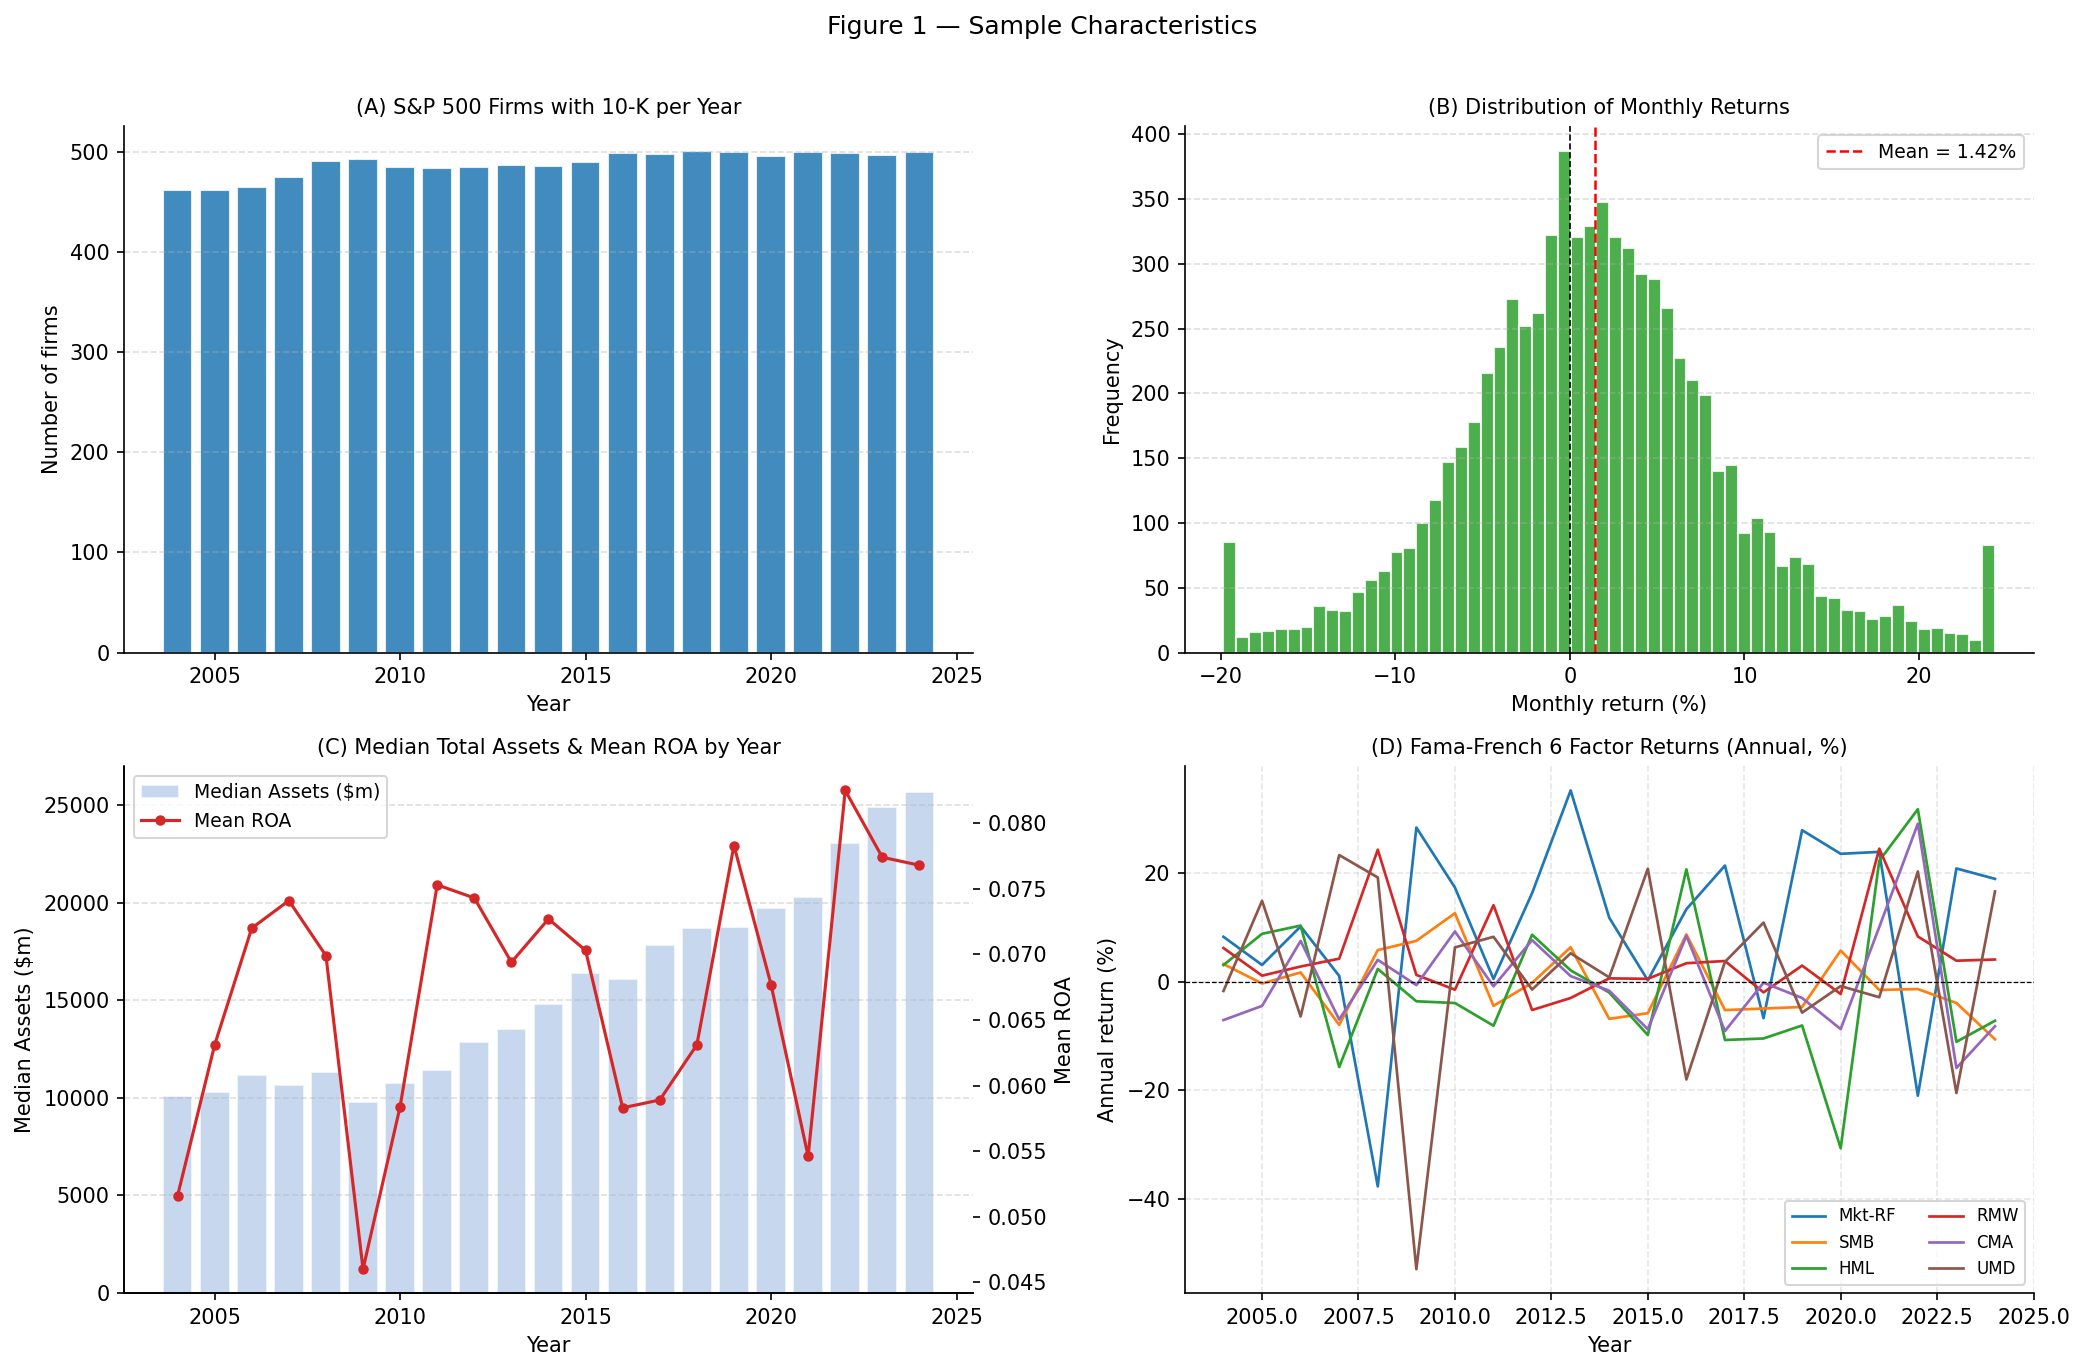

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── (A) Firms per year ────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(cov['Year'], cov['Firms'], color='#1f77b4', alpha=0.85, edgecolor='white')
ax.set_title('(A) S&P 500 Firms with 10-K per Year', fontsize=10)
ax.set_xlabel('Year'); ax.set_ylabel('Number of firms')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── (B) Distribution of monthly returns ──────────────────────────────
ax = axes[0, 1]
ax.hist(monthly['monthly_return'].dropna() * 100, bins=60,
        color='#2ca02c', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
mn = monthly['monthly_return'].mean() * 100
ax.axvline(mn, color='red', linewidth=1.2, linestyle='--',
           label=f'Mean = {mn:.2f}%')
ax.set_title('(B) Distribution of Monthly Returns', fontsize=10)
ax.set_xlabel('Monthly return (%)'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── (C) Mean assets and ROA over time ────────────────────────────────
ax = axes[1, 0]
ax2 = ax.twinx()
ax.bar(cov['Year'], cov['Median Assets ($m)'], color='#aec7e8', alpha=0.7,
       edgecolor='white', label='Median Assets ($m)')
ax2.plot(cov['Year'], cov['Mean ROA'], color='#d62728', marker='o',
         linewidth=1.5, markersize=4, label='Mean ROA')
ax.set_title('(C) Median Total Assets & Mean ROA by Year', fontsize=10)
ax.set_xlabel('Year'); ax.set_ylabel('Median Assets ($m)')
ax2.set_ylabel('Mean ROA')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── (D) FF6 factor time-series (if available) ─────────────────────────
ax = axes[1, 1]
if HAS_FF:
    factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']
    ff_ann = ff_sample[[c for c in factor_cols if c in ff_sample.columns]].resample('YE').apply(
        lambda x: (1 + x).prod() - 1
    ) * 100
    ff_ann.index = ff_ann.index.year
    colors_ff = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    for col, c in zip(ff_ann.columns, colors_ff):
        ax.plot(ff_ann.index, ff_ann[col], label=col, color=c, linewidth=1.3)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title('(D) Fama-French 6 Factor Returns (Annual, %)', fontsize=10)
    ax.set_xlabel('Year'); ax.set_ylabel('Annual return (%)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(linestyle='--', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'FF data not available', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)

plt.suptitle('Figure 1 \u2014 Sample Characteristics', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'], 'fig_descriptive_stats.pdf'),
            bbox_inches='tight')
plt.show()

## 11. LaTeX Export

In [14]:
def df_to_latex(df: pd.DataFrame, caption: str, label: str, note: str) -> str:
    ncols   = len(df.columns)
    col_fmt = 'l' + 'r' * (ncols - 1)
    header  = ' & '.join([f'\\textbf{{{c}}}' for c in df.columns]) + r' \\'
    rows    = [' & '.join(str(v) for v in r) + r' \\' for r in df.itertuples(index=False)]
    return '\n'.join([
        r'\begin{table}[htbp]',
        r'\centering',
        r'\small',
        f'\\caption{{{caption}}}',
        f'\\label{{{label}}}',
        f'\\begin{{tabular}}{{{col_fmt}}}',
        r'\toprule',
        header,
        r'\midrule',
        *rows,
        r'\bottomrule',
        r'\end{tabular}',
        f'\\begin{{tablenotes}}\\small\\item {note}\\end{{tablenotes}}',
        r'\end{table}',
    ])

note_a = ('Firm-filing observations (one per unique 10-K accession number). '
          'All variables winsorised at the 1st and 99th percentiles. '
          'Financial data from Compustat via the Lazy Prices dataset. '
          'ROA = net income / total assets; Asset Turnover = revenue / total assets; '
          'Filing Lag = months between fiscal year-end (datadate) and 10-K filing date.')

note_b = ('Firm-month observations. '
          'Monthly returns and momentum / reversal from CRSP via the Lazy Prices dataset. '
          'Momentum: cumulative log return from month $t-12$ to $t-2$. '
          'Reversal: return in month $t-1$.')

note_c = ('Monthly Fama-French six-factor returns in percent. '
          'FF5 factors (Fama \\& French 2015) plus Momentum (Carhart 1997). '
          'Downloaded from the Ken French Data Library.')

latex_a = df_to_latex(tbl_a, 'Descriptive Statistics: Firm Financial Characteristics',
                      'tab:desc_financial', note_a)
latex_b = df_to_latex(tbl_b, 'Descriptive Statistics: Return Variables',
                      'tab:desc_returns', note_b)

out_a = os.path.join(CONFIG['output_folder'], 'table_desc_financial.tex')
out_b = os.path.join(CONFIG['output_folder'], 'table_desc_returns.tex')
with open(out_a, 'w') as f: f.write(latex_a)
with open(out_b, 'w') as f: f.write(latex_b)

if HAS_FF:
    latex_c = df_to_latex(tbl_c, 'Descriptive Statistics: Fama-French Six-Factor Returns',
                          'tab:desc_ff6', note_c)
    out_c = os.path.join(CONFIG['output_folder'], 'table_desc_ff6.tex')
    with open(out_c, 'w') as f: f.write(latex_c)
    print(f'Saved: {out_c}')

print(f'Saved: {out_a}')
print(f'Saved: {out_b}')
print()
print(latex_a)

Saved: /content/drive/MyDrive/FML_project_4/table_desc_ff6.tex
Saved: /content/drive/MyDrive/FML_project_4/table_desc_financial.tex
Saved: /content/drive/MyDrive/FML_project_4/table_desc_returns.tex

\begin{table}[htbp]
\centering
\small
\caption{Descriptive Statistics: Firm Financial Characteristics}
\label{tab:desc_financial}
\begin{tabular}{lrrrrrrrrr}
\toprule
\textbf{Variable} & \textbf{N} & \textbf{Mean} & \textbf{Std Dev} & \textbf{p10} & \textbf{p25} & \textbf{Median} & \textbf{p75} & \textbf{p90} & \textbf{Skewness} \\
\midrule
Total Assets ($m) & 10,220 & 47568.4238 & 105316.9216 & 3190.9498 & 6439.1945 & 15360.4065 & 38608.0155 & 104173.3000 & 4.806 \\
log(Total Assets) & 10,220 & 9.7344 & 1.3473 & 8.0681 & 8.7702 & 9.6395 & 10.5612 & 11.5538 & 0.428 \\
Revenue ($m) & 8,492 & 19413.4691 & 33008.8490 & 2158.8747 & 4080.8678 & 8443.9855 & 17835.0000 & 44576.6000 & 3.705 \\
Net Income ($m) & 8,492 & 1576.8447 & 3122.3853 & 20.7886 & 288.2342 & 647.1310 & 1592.3250 & 4113.7892 &